# Exam 16th of January 2026, 8.00-13.00 for the course 1MS041 (Introduction to Data Science / Introduktion till dataanalys)

## Instructions:
1. Complete the problems by following instructions.
2. When done, submit this file with your solutions saved, following the instruction sheet.

This exam has 3 problems for a total of 40 points, to pass you need
20 points. The bonus will be added to the score of the exam and rounded afterwards.

## Some general hints and information:
* Try to answer all questions even if you are uncertain.
* Comment your code, so that if you get the wrong answer I can understand how you thought
this can give you some points even though the code does not run.
* Follow the instruction sheet rigorously.
* This exam is partially autograded, but your code and your free text answers are manually graded anonymously.
* If there are any questions, please ask the exam guards, they will escalate it to me if necessary.

## Tips for free text answers
* Be VERY clear with your reasoning, there should be zero ambiguity in what you are referring to.
* If you want to include math, you can write LaTeX in the Markdown cells, for instance `$f(x)=x^2$` will be rendered as $f(x)=x^2$ and `$$f(x) = x^2$$` will become an equation line, as follows
$$f(x) = x^2$$
Another example is `$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$` which renders as
$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$

## Finally some rules:
* You may not communicate with others during the exam, for example:
    * You cannot ask for help in Stack-Overflow or other such help forums during the Exam.
    * You may not communicate with AI's, for instance ChatGPT.
    * Your on-line and off-line activity is being monitored according to the examination rules.

## Good luck!

In [ ]:
# Insert your anonymous exam ID as a string in the variable below
examID="0007-FMD"


---
## Exam vB, PROBLEM 1
Maximum Points = 14


This problem is about **SVD** and a simple **anomaly detection** idea using low-rank reconstruction.



Unless stated otherwise, when you are asked to produce a matrix or vector, it must be a **NumPy array**.

1. **[4p] SVD.** Load `data/SVD.csv` as instructed in the code cell. Let $X$ be the data matrix of shape `n_samples × n_dimensions`. Compute an SVD
   $$X = U D V^T$$
   where $U$ has shape `n_samples × n_dimensions`, $D$ is the diagonal matrix of shape `(n_dimensions,n_dimensions)` that has the singular values on the diagonal (see documentation for `np.diag`), and $V$ has shape `n_dimensions × n_dimensions`.
   **Important:** `np.linalg.svd` returns `U, d, Vt` where `Vt` is $V^T$.
   Also extract the **first** right and left singular vectors and store them as 1D arrays in the variables provided.

2. **[3p] Explained variance.** For $N =$ `n_dimensions`, define the explained variance using the first $k$ singular values as
   $$
   \mathrm{EV}(k) = \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^N \sigma_i^2}.
   $$
   Compute $\mathrm{EV}(k)$ for $k=1,2,\dots,N$ and store it in `problem1_explained_variance` (length `N`). Then set `problem1_num_components` to the **smallest** $k$ such that $\mathrm{EV}(k) \ge 0.99$.

3. **[3p] Plot + interpretation.** Plot explained variance (x-axis: number of components $k$, y-axis: $\mathrm{EV}(k)$). In the markdown cell below, reason about the shape of the curve for this dataset.

4. **[4p] Low-rank reconstruction + outliers.**
   - Using `problem1_num_components`, construct the best rank-$k$ approximation of $X$ and store it in `problem1_approximation`.
   - Compute the row-wise Euclidean reconstruction error $\|X_i - \hat X_i\|_2$ for each row $i$ and store it in `problem1_reconstruction_error` (shape `(n_samples,)`).
   - Plot the empirical distribution function (EDF) of the reconstruction errors (you may use `makeEDF` / `plotEDF` from `Utils.py`).
   - Choose a threshold `problem1_threshold` so that **exactly 100** samples are flagged as outliers (i.e. have reconstruction error >= the threshold).
   - Store those flagged rows in `problem1_outliers` (shape `(100, n_dimensions)`).


In [2]:
# Part 1: 4 points

# Load the data from the file data/SVD.csv and store the data in a numpy array called problem1_data below
# Double check that the numbers have been parsed correctly by checking the dtype of the array by calling problem1_data.dtype
import pandas as pd
import numpy as np

problem1_data = pd.read_csv('data/SVD.csv').to_numpy() # shape: n_samples x n_dimensions

# np.linalg.svd returns U, singular values d, and Vt = V^T
U, d, Vt = np.linalg.svd(problem1_data, full_matrices=False)

problem1_U = U
problem1_D = np.diag(d)
problem1_V = Vt.T

# First right singular vector = first column of V = first row of Vt
problem1_first_right_singular_vector = Vt[0, :].flatten()

# First left singular vector = first column of U
problem1_first_left_singular_vector = U[:, 0].flatten()


In [3]:
# Part 2: 3 points

# Calculate the explained variance of using 1,2,3,...,n_dimensions singular values and store it as a numpy array called problem1_explained_variance below
singular_values = np.diag(problem1_D)

problem1_explained_variance = np.cumsum(singular_values**2) / np.sum(singular_values**2)

# Store in the variable below the smallest number of singular values needed to explain at least 99% of the variance
problem1_num_components = int(np.searchsorted(problem1_explained_variance, 0.99) + 1)


NameError: name 'XXX' is not defined

In [4]:
# Part 3: 3 points

# Put the code below to plot the explained variance
# use for instance matplotlib
import matplotlib.pyplot as plt

ks = np.arange(1, len(problem1_explained_variance) + 1)

plt.plot(ks, problem1_explained_variance, marker='o')
plt.axhline(0.99, linestyle='--')
plt.xlabel("Number of singular values/components k")
plt.ylabel("Explained variance EV(k)")
plt.title("Explained variance from SVD")
plt.grid(True)
plt.show()


## Free-text answer (Part 3)

The explained-variance curve should increase quickly at first and then flatten out near 1. This means the first few singular values explain most of the structure in the data, while the later singular values add only small extra information. For this dataset, that shape suggests the data has a strong low-rank pattern plus smaller noise/details.


In [5]:
# Part 4: 4 points

# Calculate the approximating matrix of problem1_data using the first problem1_num_components singular values and store it in the variable below
k = problem1_num_components

# X_k = U_k D_k V_k^T
problem1_approximation = problem1_U[:, :k] @ problem1_D[:k, :k] @ problem1_V[:, :k].T

# Calculate the reconstruction error of problem1_data using problem1_approximation and store it in the variable below (should have shape (n_samples,)) (row wise Euclidean distance)
problem1_reconstruction_error = np.linalg.norm(problem1_data - problem1_approximation, axis=1)

# Put the code below to plot the empirical distribution function of the reconstruction error
# You can use the Utils.py file for plotting the empirical distribution function, makeEDF and plotEDF functions
try:
    from Utils import makeEDF, plotEDF
    x_edf, y_edf = makeEDF(problem1_reconstruction_error)
    plotEDF(x_edf, y_edf)
except Exception:
    sorted_errors = np.sort(problem1_reconstruction_error)
    edf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    plt.plot(sorted_errors, edf)
    plt.xlabel("Reconstruction error")
    plt.ylabel("Empirical distribution function")
    plt.title("EDF of reconstruction error")
    plt.grid(True)
    plt.show()

# Select the 100 largest reconstruction errors as outliers.
# A threshold just below the 100th largest error makes those 100 points exceed the threshold.
sorted_errors = np.sort(problem1_reconstruction_error)
problem1_threshold = np.nextafter(sorted_errors[-100], -np.inf)

problem1_outliers = problem1_data[problem1_reconstruction_error > problem1_threshold]

# Safety fallback in case there are exact ties causing more/less than 100 rows
if problem1_outliers.shape[0] != 100:
    outlier_indices = np.argsort(problem1_reconstruction_error)[-100:]
    problem1_outliers = problem1_data[outlier_indices]


NameError: name 'XXX' is not defined

In [6]:
# EXAM vB, TEST 1, POINTS 14

Beginning tests for problem 1

---------------------------------
Beginning test for part1
---------------------------------

-----Beginning diagnostic test------
You forgot to skip the header
-----Ending test---------

-----Beginning test------

The shape of the data is not correct
You got 1.0 points deduction 
-----Ending test---------

You stored V^T instead of V; transposing for the remaining tests.
-----Beginning test------
The left singular vectors have the correct shape
-----Ending test---------

-----Beginning test------
The matrix of singular values have the correct shape
-----Ending test---------

-----Beginning test------
The SVD decomposition recovers the original matrix
-----Ending test---------

-----Beginning test------
The right singular vectors have the correct shape
-----Ending test---------

-----Beginning test------
The first right singular vector has the correct shape
-----Ending test---------

-----Beginning test------
The first left singular vector has the correct

---
## Exam vB, PROBLEM 2
Maximum Points = 12


In this problem we are interested in **account takeover (ATO) detection** for an online service. You are given the outputs of a classifier that predicts the probability that a login attempt is malicious ($Y=1$). Your goal is to explore how the **decision threshold** affects business cost (as in the thresholding assignment).

A threshold $t \in [0,1]$ is used to convert predicted probabilities $\hat p(x)=P(Y=1\mid x)$ to labels: predict $\hat y=1$ if $\hat p(x)\ge t$, else $\hat y=0$.

The costs associated with the decisions are:

* **True Positive (TP)**: correctly flagging an ATO login costs **80** (extra verification + friction).
* **True Negative (TN)**: allowing a legitimate login has **0** cost.
* **False Positive (FP)**: incorrectly flagging a legitimate login costs **150** (support load + churn risk).
* **False Negative (FN)**: missing an ATO login costs **900** (fraud + remediation).

**The code cells contain more detailed instructions; THE FIRST CODE CELL INITIALIZES YOUR VARIABLES.**

1. **[3p]** Complete the function `problem2_avg_cost` to compute the **average cost per sample** of a model under a certain prediction threshold. Plot the cost as a function of the threshold (using the validation data provided in the first code cell of this problem), from 0 to 1 with step size 0.01.
2. **[2.5p]** Find the threshold that minimizes the cost and calculate the cost at that threshold on the validation data. Also calculate the precision and recall at the optimal threshold, treating **class 1 as the positive class** and **class 0 as the positive class** separately.
3. **[2.5p]** Repeat step 2, but this time find the best threshold to **maximize accuracy** (equivalently, minimize the $0{-}1$ loss). Calculate the difference in cost between the threshold found in part 3 and the one found in part 2.
4. **[4p]** Provide a confidence interval around the optimal cost (with $95\%$ confidence) applied to the test data using **Hoeffding's inequality**, and explain all assumptions you made.

In [7]:

# RUN THIS CELL TO GET THE DATA

# We start by loading the data 
import pandas as pd

PROBLEM2_DF = pd.read_csv('data/fraud.csv')
Y = PROBLEM2_DF['Class'].values
X = PROBLEM2_DF[['V%d' % i for i in range(1,5)]+['Amount']].values

# We will split the data into training, testing and validation sets
from Utils import train_test_validation
PROBLEM2_X_train, PROBLEM2_X_test, PROBLEM2_X_val, PROBLEM2_y_train, PROBLEM2_y_test, PROBLEM2_y_val = train_test_validation(X,Y,shuffle=True,random_state=1)



# From this we will train a logistic regression model with scaling and simple hyperparameter search
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=1000, random_state=1))
])

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__class_weight': [None, 'balanced']
}

gs = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
gs.fit(PROBLEM2_X_train, PROBLEM2_y_train)

# use the best pipeline (it supports predict_proba)
lr = gs.best_estimator_

# THE FOLLOWING CODE WILL PRODUCE THE ARRAYS YOU NEED FOR THE PROBLEM
PROBLEM2_y_pred_proba_val = lr.predict_proba(PROBLEM2_X_val)[:,1]
PROBLEM2_y_true_val = PROBLEM2_y_val

PROBLEM2_y_pred_proba_test = lr.predict_proba(PROBLEM2_X_test)[:,1]
PROBLEM2_y_true_test = PROBLEM2_y_test

# Store the fitted best model and the arrays used in the later parts
PROBLEM2_model = gs.best_estimator_

PROBLEM2_y_true_val = PROBLEM2_y_val
PROBLEM2_y_true_test = PROBLEM2_y_test

PROBLEM2_y_pred_proba_val = PROBLEM2_model.predict_proba(PROBLEM2_X_val)[:, 1]
PROBLEM2_y_pred_proba_test = PROBLEM2_model.predict_proba(PROBLEM2_X_test)[:, 1]


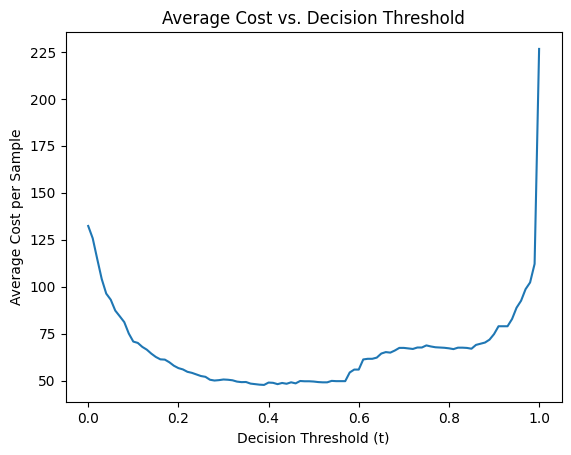

In [8]:
# Part 1: 3 points
# Implement the following function that calculates the average cost per sample of a binary classifier
# according to the specification in the problem statement.
import numpy as np
import matplotlib.pyplot as plt

def problem2_avg_cost(y_true, y_predict_proba, threshold):
    # y_true: true labels, 1 = malicious ATO, 0 = legitimate
    # y_predict_proba: predicted probabilities for class 1
    # threshold: classify as 1 if probability >= threshold

    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_predict_proba) >= threshold).astype(int)

    tp = (y_true == 1) & (y_pred == 1)
    tn = (y_true == 0) & (y_pred == 0)
    fp = (y_true == 0) & (y_pred == 1)
    fn = (y_true == 1) & (y_pred == 0)

    individual_costs = (
        80 * tp.astype(float)
        + 0 * tn.astype(float)
        + 150 * fp.astype(float)
        + 900 * fn.astype(float)
    )

    return float(np.mean(individual_costs))


# Plot cost as a function of threshold on validation data
thresholds = np.arange(0, 1.01, 0.01)
costs = np.array([problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, t) for t in thresholds])

plt.plot(thresholds, costs)
plt.xlabel("Decision threshold")
plt.ylabel("Average cost per sample")
plt.title("Average cost vs threshold")
plt.grid(True)
plt.show()


In [9]:
# Part 2: 2.5 points

# Use the cost function to find the threshold that minimizes average cost on validation data
from sklearn.metrics import precision_score, recall_score

min_cost_index = int(np.argmin(costs))
problem2_threshold = float(thresholds[min_cost_index])

# Average validation cost at the cost-optimal threshold
problem2_cost_val = float(costs[min_cost_index])

# Predicted labels on validation data using cost-optimal threshold
problem2_y_pred_val = (PROBLEM2_y_pred_proba_val >= problem2_threshold).astype(int)

# Precision and recall for class 1
problem2_precision_1 = precision_score(PROBLEM2_y_true_val, problem2_y_pred_val, pos_label=1, zero_division=0)
problem2_recall_1 = recall_score(PROBLEM2_y_true_val, problem2_y_pred_val, pos_label=1, zero_division=0)

# Precision and recall for class 0
problem2_precision_0 = precision_score(PROBLEM2_y_true_val, problem2_y_pred_val, pos_label=0, zero_division=0)
problem2_recall_0 = recall_score(PROBLEM2_y_true_val, problem2_y_pred_val, pos_label=0, zero_division=0)


In [ ]:
# Part 3

from sklearn.metrics import accuracy_score
import numpy as np

# Calculate accuracy for every threshold
accuracies = [
    accuracy_score(
        PROBLEM2_y_true_val,
        (PROBLEM2_y_pred_proba_val >= t).astype(int)
    )
    for t in thresholds
]

# Find the threshold with maximum accuracy
max_accuracy_index = np.argmax(accuracies)

problem2_threshold_acc = float(thresholds[max_accuracy_index])

# Calculate cost at the accuracy-optimal threshold
cost_at_acc_threshold = problem2_avg_cost(
    PROBLEM2_y_true_val,
    PROBLEM2_y_pred_proba_val,
    problem2_threshold_acc
)

# Difference in cost:
# cost at accuracy-optimal threshold minus cost at cost-optimal threshold
problem2_cost_difference = float(cost_at_acc_threshold - problem2_cost_val)

print("Accuracy-optimal threshold:", problem2_threshold_acc)
print("Accuracy at this threshold:", accuracies[max_accuracy_index])
print("Cost at accuracy-optimal threshold:", cost_at_acc_threshold)
print("Cost at cost-optimal threshold:", problem2_cost_val)
print("Cost difference:", problem2_cost_difference)


In [11]:
# Part 4: 4 points

# Using the cost-optimal threshold from part 2, apply Hoeffding's inequality
# to provide a 95% confidence interval for the average cost on the test data.

y_pred_test = (PROBLEM2_y_pred_proba_test >= problem2_threshold).astype(int)

tp = (PROBLEM2_y_true_test == 1) & (y_pred_test == 1)
tn = (PROBLEM2_y_true_test == 0) & (y_pred_test == 0)
fp = (PROBLEM2_y_true_test == 0) & (y_pred_test == 1)
fn = (PROBLEM2_y_true_test == 1) & (y_pred_test == 0)

individual_costs = (
    80 * tp.astype(float)
    + 0 * tn.astype(float)
    + 150 * fp.astype(float)
    + 900 * fn.astype(float)
)

avg_test_cost = float(np.mean(individual_costs))

n_test = len(PROBLEM2_y_true_test)
alpha = 0.05

# Hoeffding for bounded random variables in [0,900]:
# P(|mean - expected mean| >= eps) <= 2 exp(-2 n eps^2 / (900 - 0)^2)
cost_range = 900 - 0
epsilon = np.sqrt((cost_range**2 * np.log(2 / alpha)) / (2 * n_test))

problem2_lower_bound = avg_test_cost - epsilon
problem2_upper_bound = avg_test_cost + epsilon


## Free text answer

Hoeffding's inequality applies approximately because the test examples are treated as independent samples from the same distribution, and after the threshold is fixed using the validation set, each test example gives one bounded cost value. The random variables are the per-sample costs on the test set, assumed i.i.d., with possible values 0, 80, 150, or 900. Therefore every cost lies in the interval $[0,900]$, so the cost range used in Hoeffding's inequality is $C_{\max}-C_{\min}=900-0=900$.


In [12]:
# EXAM vB, TEST 2, POINTS 12

Beginning tests for problem 2

---------------------------------
Beginning test for part1
---------------------------------

-----Beginning test------
Your average cost function is correct on a small example using threshold 0.49
-----Ending test---------

-----Beginning test------
Your average cost function is correct on a small example using threshold 0.2
-----Ending test---------

-----Beginning test------
Your average cost function is correct on the validation data using threshold 0.1
-----Ending test---------

Manual points: 0
No comment!
---------------------------------
Beginning test for part2
---------------------------------

-----Beginning test------
Your threshold minimizes the cost you supplied
-----Ending test---------

-----Beginning test------
Your cost is correct using the threshold you found
-----Ending test---------

-----Beginning test------
You get a deduction for each mistake in the predicted labels: deduced_points 0.00
-----Ending test---------

-----Beginning tes

---
## Exam vB, PROBLEM 3
Maximum Points = 14


A courier company monitors its trucks across four states:

*   **Downtown (D)**
*   **Suburbs (S)**
*   **Countryside (C)**
*   **Maintenance (M)** 

The transition probabilities between states at each time step are given by the matrix:

| Current State | D    | S    | C    | M    |
| ------------- | ---- | ---- | ---- | ---- |
| D             | 0.25 | 0.35 | 0.30 | 0.10 |
| S             | 0.20 | 0.40 | 0.30 | 0.10 |
| C             | 0.15 | 0.35 | 0.40 | 0.10 |
| M             | 0.00 | 0.00 | 0.00 | 1.00 |

1. If a truck starts in the **Suburbs**, what is the probability that it eventually ends up in **Maintenance**? [1p]
2. If a truck starts in **Downtown**, what is the probability that it will be in **Countryside** after five time steps? [2p]
3. Starting from **Downtown**, what is the expected number of steps before entering **Maintenance**? [3p] \
    **Hint**:
    To compute approximatively you could **simulate** but this gives a max score of [1.5p].
    To compute exactly use first-step analysis: 
$$
\text{Expected time from a state} = 1 + \sum_{\text{next states}} \big( \text{transition probability} \times \text{expected time from next state} \big)
$$

4. Is this Markov chain irreducible? Is it aperiodic? [2p]
5. Does this chain have a stationary distribution? If yes, compute it; if not, explain why. [2p]
6. Given that the truck starts in **Countryside** what is the probability that **the last state visited** before reaching **Maintenance** is **Suburbs**? [4p]  
**Hint**: To compute approximatively you could **simulate** but this gives a max score of [2p]. To compute exactly use first-step analysis: Let $f_D, f_S, f_C$ be the probabilities that the last state before hitting Maintenance is Suburbs, starting from Downtown, Suburbs, and Countryside respectively. Write recursive equations by conditioning on the next step. This gives a linear system to solve.


In [1]:
# Part 1

# Fill in the answer to part 1 below as a decimal number (float)
# If a truck starts in the Suburbs, what is the probability that it eventually ends up in Maintenance?
import numpy as np

P = np.array([
    [0.25, 0.35, 0.30, 0.10],
    [0.20, 0.40, 0.30, 0.10],
    [0.15, 0.35, 0.40, 0.10],
    [0.00, 0.00, 0.00, 1.00]
])

# transient states: D, S, C
Q = P[:3, :3]

# probabilities of going directly to Maintenance from D, S, C
r = P[:3, 3]

# solve absorption probabilities:
# h = Qh + r
# (I - Q)h = r
I = np.eye(3)

h = np.linalg.solve(I - Q, r)

# starting from Suburbs = index 1
problem3_prob_maintenance_from_suburbs = float(h[1])

print(h)
print(problem3_prob_maintenance_from_suburbs)


[1. 1. 1.]
1.0000000000000004


In [14]:
# Part 2

# Fill in the answer to part 2 below as a decimal number (float)
# If a truck starts in Downtown, what is the probability that it will be in Countryside after five time steps?
import numpy as np

P = np.array([
    [0.25, 0.35, 0.30, 0.10],
    [0.20, 0.40, 0.30, 0.10],
    [0.15, 0.35, 0.40, 0.10],
    [0.00, 0.00, 0.00, 1.00]
])

problem3_prob_countryside_after_5_steps = float(np.linalg.matrix_power(P, 5)[0, 2])


In [15]:
# Part 3

# Fill in the answer to part 3 below as a decimal number (float)
# Starting from Downtown, what is the expected number of steps before entering Maintenance?

# Let t_D, t_S, t_C be expected steps to hit Maintenance.
# t = 1 + Q t, where Q is the transient-to-transient transition matrix.
Q = P[:3, :3]
problem3_expected_steps_downtown = float(np.linalg.solve(np.eye(3) - Q, np.ones(3))[0])


In [16]:
# Part 4

# Fill in the answers to part 4 below as booleans (use True or False)
# Is this Markov chain irreducible? Is it aperiodic?
problem3_is_irreducible = False
problem3_is_aperiodic = True


In [17]:
# Part 5

# Fill in the answer to part 5 below (if it exists)
# The answer should be a numpy array of length 4 whose entries sum to 1.
# If it does not exist, write None instead of an array.
import numpy as np

problem3_stationary_distribution = np.array([0.0, 0.0, 0.0, 1.0])


## Free text answer (Part 5)

Yes, the chain has a stationary distribution. Maintenance is an absorbing state, so once the truck enters Maintenance it stays there forever. Since the other three states can eventually move to Maintenance, the long-run stationary distribution is all mass on Maintenance: $[0,0,0,1]$.


In [19]:
# Part 6

# Fill in the answer to part 6 below as a decimal number (float)
# Given that the truck starts in Countryside, what is the probability that the last state visited before reaching Maintenance is Suburbs?

# Let f_D, f_S, f_C be the probability that the last state before Maintenance is Suburbs.
# If we jump directly to Maintenance from S, this is success; from D or C, it is failure.
# f = Q f + b, where b = [0, P(S->M), 0].
b = np.array([0.0, 0.10, 0.0])
f = np.linalg.solve(np.eye(3) - Q, b)

problem3_prob_last_suburbs_from_countryside = float(f[2])


In [20]:
# EXAM vB, TEST 3, POINTS 14

Beginning tests for PROBLEM 3

---------------------------------
Beginning test for part1
---------------------------------

-----Beginning test------
Your probability is correct!
-----Ending test---------

---------------------------------
Beginning test for part2
---------------------------------

-----Beginning test------
Your probability is correct!
-----Ending test---------

---------------------------------
Beginning test for part3
---------------------------------

Note: There are two tests here, one for the exact calculation and one for the simulation.
 If you pass both you have the exact answer. 
 If you pass only the simulation test, you are close enough to the correct answer.
-----Beginning test------
Your expected number of steps is correct (exact)!
-----Ending test---------

-----Beginning test------
Your expected number of steps is correct (simulation)!
-----Ending test---------

---------------------------------
Beginning test for part4
---------------------------------
